# Imports

In [1]:
import math
import matplotlib.pyplot as plt
import numpy as np

from scipy.stats import norm

# Vanilla European Option Pricing by Black-Scholes and Put-Call Parity

In [8]:
S = 100 # Stock Price
K = 100 # Strike Price
r = 0.05 # Risk-free rate (over a year)
sigma = 0.25 # Vol parameter (note that volatility = sigma * sqrt(# of periods in time horizon))
T = 0.2 # Time to expiry in years

In [9]:
d1 = 1 / (sigma * math.sqrt(T)) * (math.log(S / K) + (r + sigma**2 / 2) * T)
d2 = d1 - sigma * math.sqrt(T)

In [10]:
# Call price by BS
C = norm.cdf(d1) * S - norm.cdf(d2) * K * math.exp(-r * T)
print(f'Call price by BS: ${C:.3f}')

# Put price by put-call parity
D = 1 / (1 + r * T)
P = C - S + D * K
print(f'Put price by PCP: ${P:.3f}')


Call price by BS: $4.951
Put price by PCP: $3.961


In [11]:
# Put price by BS
P = norm.cdf(-d2) * K * math.exp(-r * T) - norm.cdf(-d1) * S
print(f'Put price by BS: ${P:.3f}')

# Call price by put-call parity
C = P + S - D * K
print(f'Call price by PCP: ${C:.3f}')

Put price by BS: $3.956
Call price by PCP: $4.946


### Dedicated Functions for Vanilla European Option Pricing Using Black-Scholes

In [12]:
def call_bs(S, K, r, sigma, T):
    '''Call price function (Black-Scholes)'''
    d1 = 1 / (sigma * math.sqrt(T)) * (math.log(S / K) + (r + sigma**2 / 2) * T)
    d2 = d1 - sigma * math.sqrt(T)
    return round(norm.cdf(d1) * S - norm.cdf(d2) * K * math.exp(-r * T), 3)

call_bs(S=110, K=100, r=0.085, sigma=0.8445, T=92/365)

24.156

In [13]:
def put_bs(S, K, r, sigma, T):
    '''Put price function (Black-Scholes)'''
    d1 = 1 / (sigma * math.sqrt(T)) * (math.log(S / K) + (r + sigma**2 / 2) * T)
    d2 = d1 - sigma * math.sqrt(T)
    return round(norm.cdf(-d2) * K * math.exp(-r * T) - norm.cdf(-d1) * S, 3)

put_bs(S=110, K=100, r=0.085, sigma=0.8445, T=92/365)

12.037

In [14]:
# Calculate call and put prices for many underlying prices
underlyings = np.arange(10, 201, 10)
call_prices_bs = np.array([call_bs(underlying, 100, 0.085, 0.8445, 92/365) for underlying in underlyings])
put_prices_bs = np.array([put_bs(underlying, 100, 0.085, 0.8445, 92/365) for underlying in underlyings])

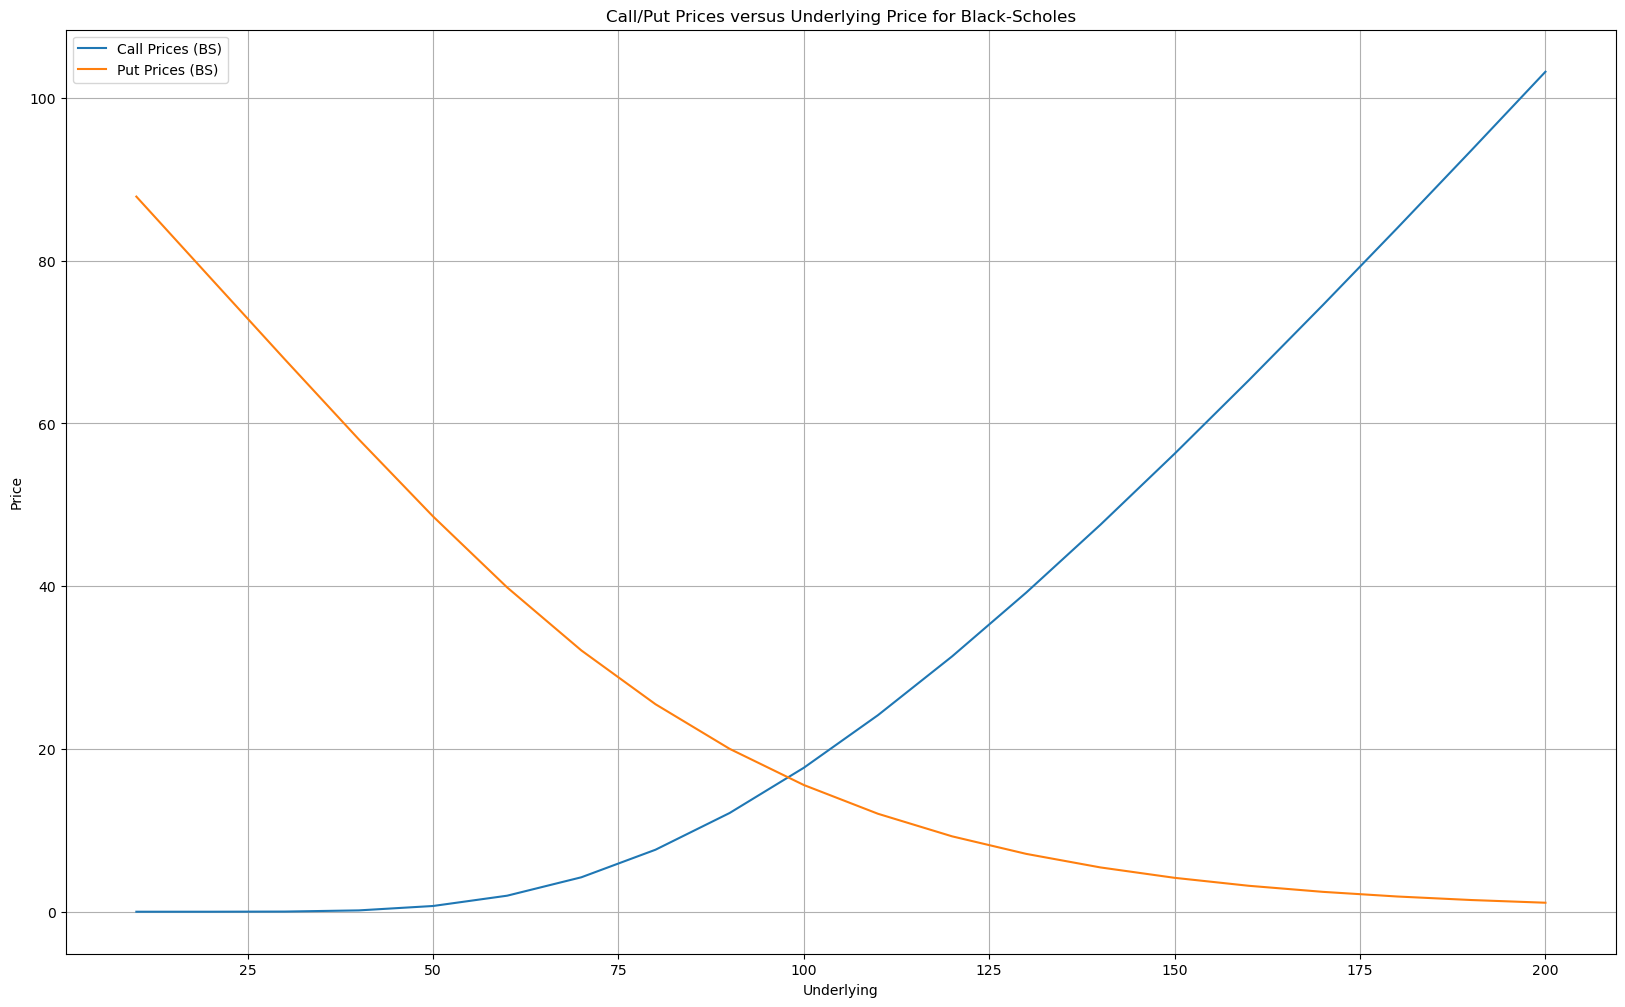

In [15]:
plt.figure(figsize=(20,12))
plt.plot(underlyings, call_prices_bs, label='Call Prices (BS)')
plt.plot(underlyings, put_prices_bs, label='Put Prices (BS)')

plt.xlabel('Underlying')
plt.ylabel('Price')
plt.legend()
plt.title('Call/Put Prices versus Underlying Price for Black-Scholes')
plt.grid()
plt.show()


### Closed-form Delta via Black-Scholes Derivatives

In [16]:
def call_delta_bs(S, K, r, sigma, T):
    '''Call delta function (Black-Scholes)'''
    d1 = 1 / (sigma * math.sqrt(T)) * (math.log(S / K) + (r + sigma**2 / 2) * T)
    return norm.cdf(d1)

def put_delta_bs(S, K, r, sigma, T):
    '''Put delta function (Black-Scholes)'''
    return call_delta_bs(S, K, r, sigma, T) - 1

In [17]:
# Calculate call and put deltas for many underlying prices
call_deltas_bs =  np.array([call_delta_bs(underlying, 100, 0.085, 0.8445, 92/365) for underlying in underlyings])
put_deltas_bs =  np.array([put_delta_bs(underlying, 100, 0.085, 0.8445, 92/365) for underlying in underlyings])

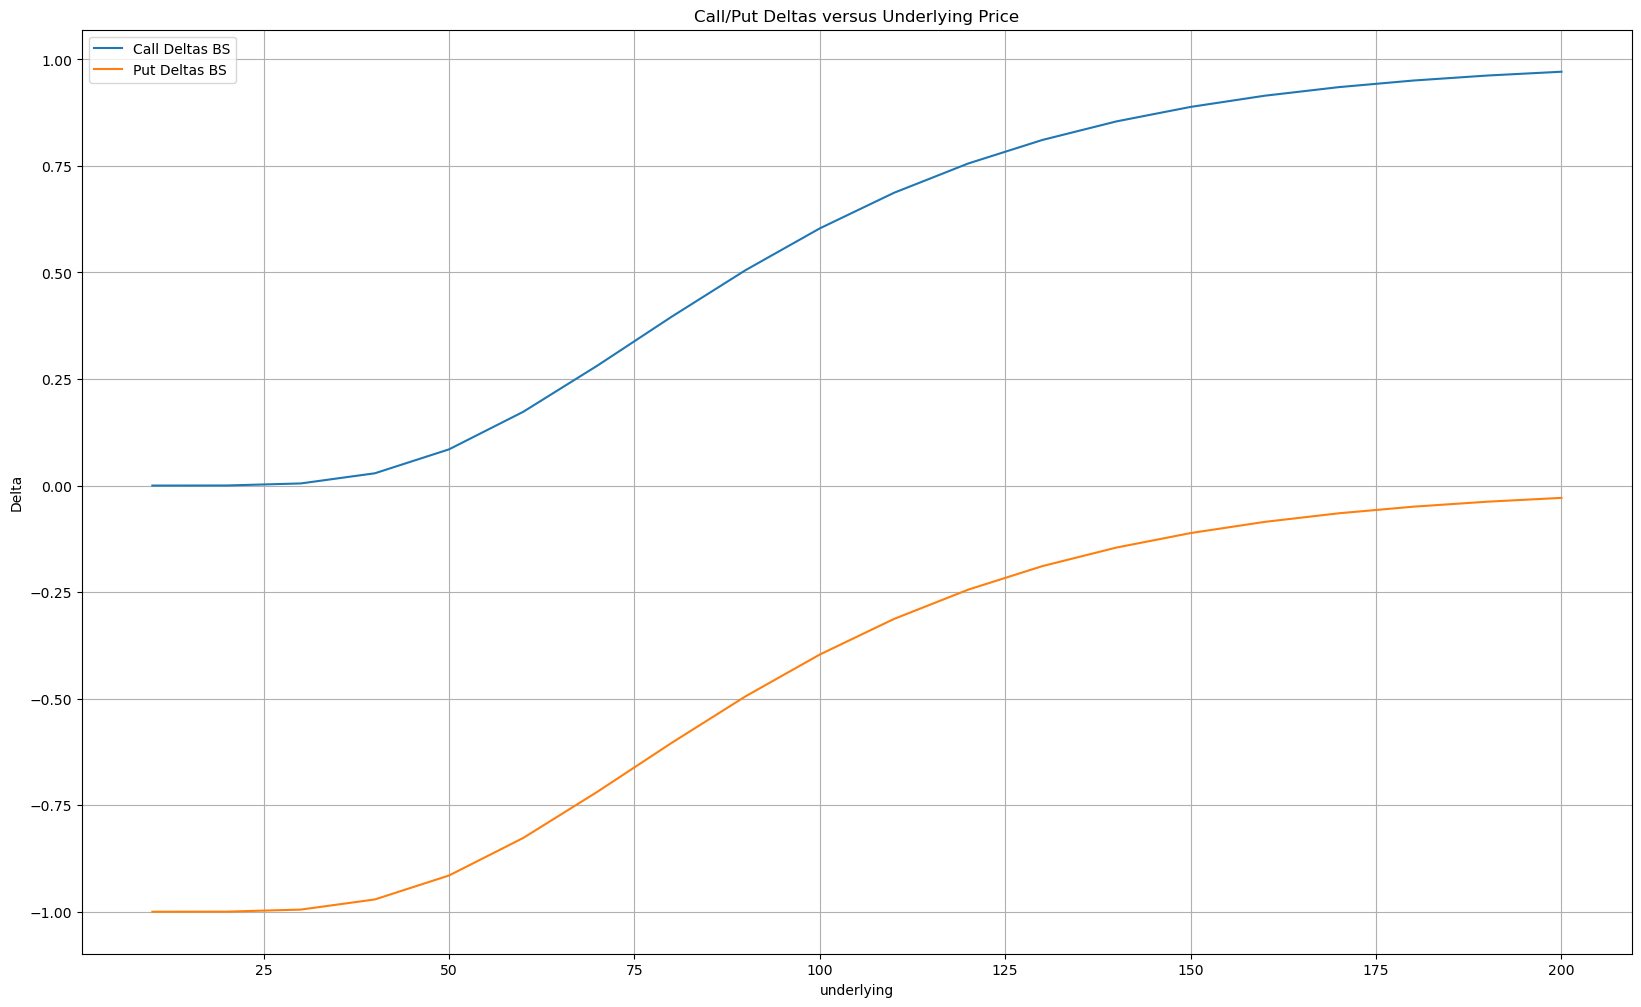

In [18]:
plt.figure(figsize=(20,12))
plt.plot(underlyings, call_deltas_bs, label='Call Deltas BS')
plt.plot(underlyings, put_deltas_bs, label='Put Deltas BS')

plt.xlabel('underlying')
plt.ylabel('Delta')
plt.legend()
plt.title('Call/Put Deltas versus Underlying Price')
plt.grid()
plt.show()

## Monte Carlo for Vanilla European Option Pricing

In [ ]:
S0 = 110
K = 100
r = 0.085
sigma = 0.8445

n = 5 # Number of MC repetitions
N = 10000 # Number of paths generated per repetition

M = 252 # Steps per year
deltat = 1 / M # Length of step increment in years
T = 92/365 # Years til expiry

call_prices = np.zeros(n) # Array to hold call prices found from each repetition
put_prices = np.zeros(n) # Array to hold put prices found from each repetition

for nn in range(0, n): # For each MC repetition
    stock_prices = np.ones(N) * S0 # Array to hold all stock paths generated for a single repetition
    call_payoffs = np.zeros(N) # Array to calculate the payoff of each stock path for a call
    put_payoffs = np.zeros(N) # Array to calculate the payoff of each stock path for a put
    for j in range(0, N): # For each path of the N paths in a single run
        for i in range(1, int(T * M + 1)): # For every time increment of a single path
            stock_prices[j] = stock_prices[j] * math.exp((r - 0.5 * sigma**2) * deltat + sigma * math.sqrt(deltat) * np.random.normal(0,1))
        # Call
        if stock_prices[j] > K:
            call_payoffs[j] = stock_prices[j] - K
        # Put
        if stock_prices[j] < K:
            put_payoffs[j] = K - stock_prices[j]

    call_prices[nn] = call_payoffs.mean() * math.exp(-r * T)
    put_prices[nn] = put_payoffs.mean() * math.exp(-r * T)

call_price_mc = call_prices.mean()
put_price_mc = put_prices.mean()


In [5]:
# Price of call using Monte Carlo
print(f'Price of call option using Monte Carlo: {call_price_mc:.3f}')

# Price of put using Monte Carlo
print(f'Price of put option using Monte Carlo: {put_price_mc:.3f}')

Price of call option using Monte Carlo: 24.244
Price of put option using Monte Carlo: 12.014


### Extending Monte Carlo for numerous underlyings to compare against Black-Scholes

In [6]:
def options_mc(S0, K, r, sigma, n, N, M, T):

    deltat = 1 / M # Length of step increment in years

    call_prices = np.zeros(n) # Array to hold call prices found from each repetition
    put_prices = np.zeros(n) # Array to hold put prices found from each repetition

    for nn in range(0, n): # For each MC repetition
        stock_prices = np.ones(N) * S0 # Array to hold all stock paths generated for a single repetition
        call_payoffs = np.zeros(N) # Array to calculate the payoff of each stock path for a call
        put_payoffs = np.zeros(N) # Array to calculate the payoff of each stock path for a put
        for j in range(0, N): # For each path of the N paths in a single run
            for i in range(1, int(T * M + 1)): # For every time increment of a single path
                stock_prices[j] = stock_prices[j] * math.exp((r - 0.5 * sigma**2) * deltat + sigma * math.sqrt(deltat) * np.random.normal(0,1))
            # Call
            if stock_prices[j] > K:
                call_payoffs[j] = stock_prices[j] - K
            # Put
            if stock_prices[j] < K:
                put_payoffs[j] = K - stock_prices[j]

        call_prices[nn] = call_payoffs.mean() * math.exp(-r * T)
        put_prices[nn] = put_payoffs.mean() * math.exp(-r * T)

    call_price_mc = call_prices.mean()
    put_price_mc = put_prices.mean()

    return call_price_mc, put_price_mc


In [7]:
underlyings = np.arange(10, 201, 10)
K = 100
r = 0.085
sigma = 0.8445

n = 2 # Number of repetitions
N = 10000 # Number of paths generated per repetition

M = 252 # Steps per year

call_prices_mc = np.zeros(len(underlyings))
put_prices_mc = np.zeros(len(underlyings))

for count, underlying in enumerate(underlyings):
    call_prices_mc[count], put_prices_mc[count] = options_mc(underlying, K, r, sigma, n, N, M, T)

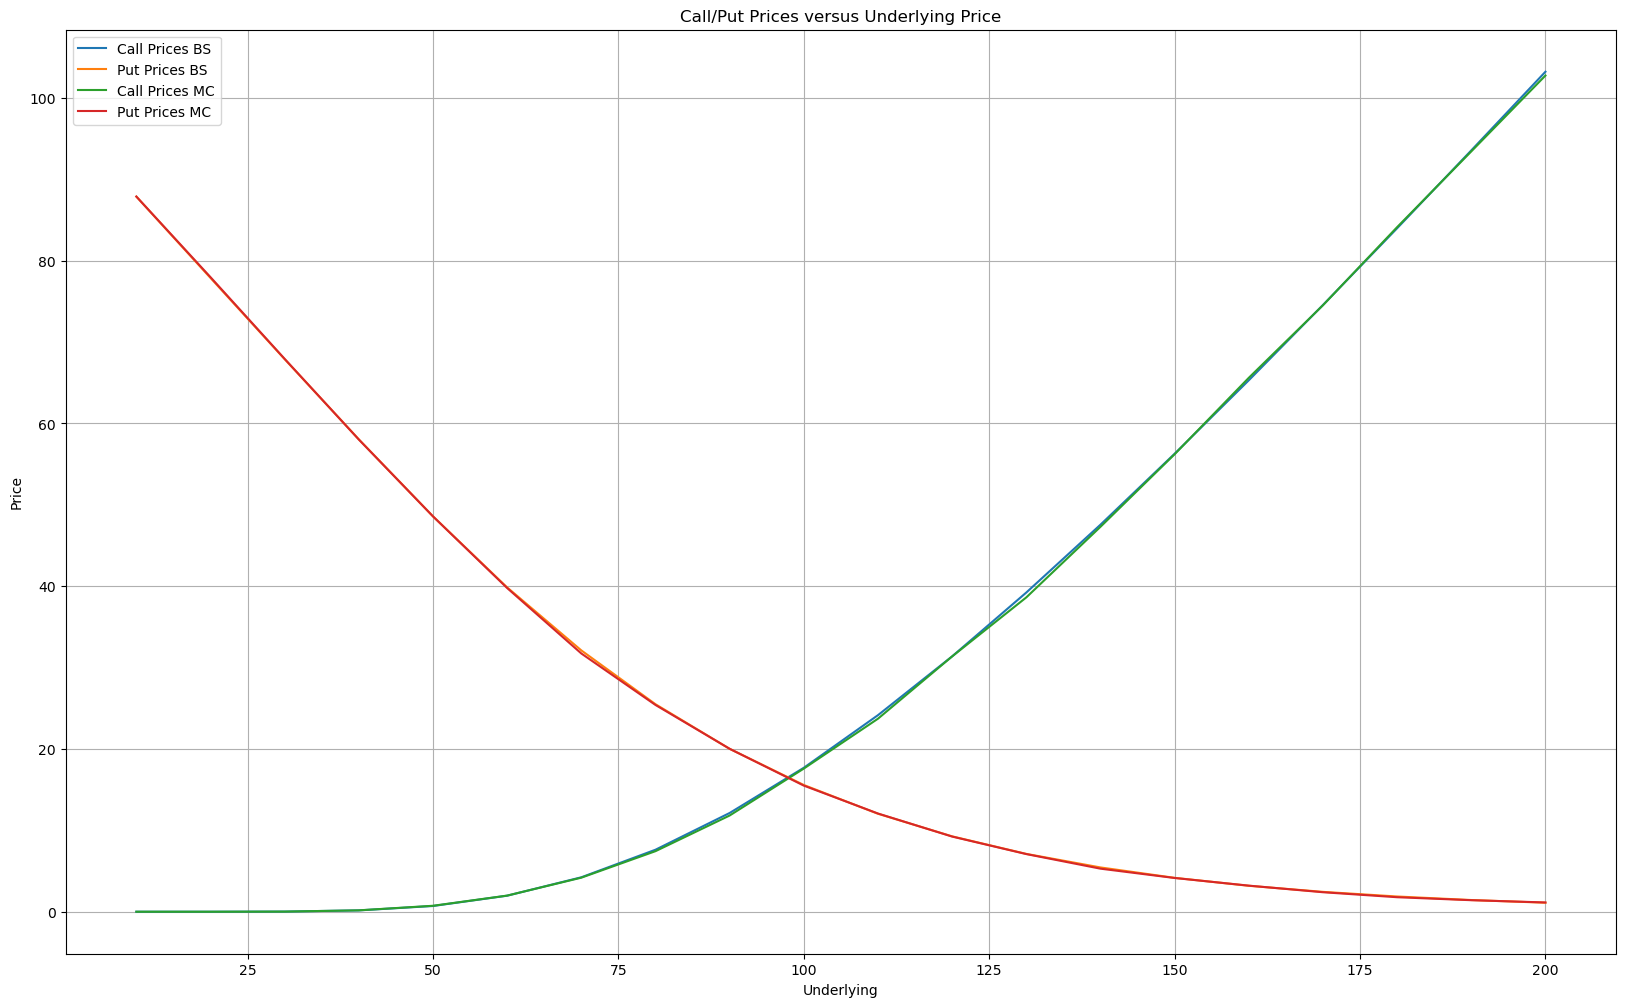

In [19]:
plt.figure(figsize=(20,12))
plt.plot(underlyings, call_prices_bs, label='Call Prices BS')
plt.plot(underlyings, put_prices_bs, label='Put Prices BS')
plt.plot(underlyings, call_prices_mc, label='Call Prices MC')
plt.plot(underlyings, put_prices_mc, label='Put Prices MC')

plt.xlabel('Underlying')
plt.ylabel('Price')
plt.legend()
plt.title('Call/Put Prices versus Underlying Price')
plt.grid()
plt.show()